In [1]:
import jax 
import jax.numpy as jnp

import matplotlib.pyplot as plt
from functools import partial

from probjax.utils.odeint import _odeint
import optax

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [2]:
def lorentz_drift(t, x, sigma=10., beta=8./3, rho=28.):
    """Lorentz system."""
    x0, x1, x2 = x
    dx0 = sigma * (x1 - x0)
    dx1 = x0 * (rho - x2) - x1
    dx2 = x0 * x1 - beta * x2
    return jnp.stack([dx0, dx1, dx2])

t = jnp.linspace(0, 80, 600)

@jax.vmap
def sample_p(key):
    x0 = jax.random.normal(key, (3,))
    ys = _odeint(lorentz_drift, x0, t, method="dopri5", atol=1e-8, rtol=1e-8)
    return ys

@jax.vmap
def sample_q(key):
    x0 = jax.random.normal(key, (3,))*1.3 + 0.1
    ys = _odeint(lorentz_drift, x0, t, 9.5, 8./3, 25., atol=1e-8, rtol=1e-8, method="dopri5")
    return ys

In [3]:
key = jax.random.PRNGKey(0)

In [4]:
samples_p = sample_p(jax.random.split(key, 200))

In [5]:
samples_p2 = sample_p(jax.random.split(key + 2, 200))

In [6]:
samples_q = sample_q(jax.random.split(key+ 1, 200))

MovieWriter imagemagick unavailable; using Pillow instead.


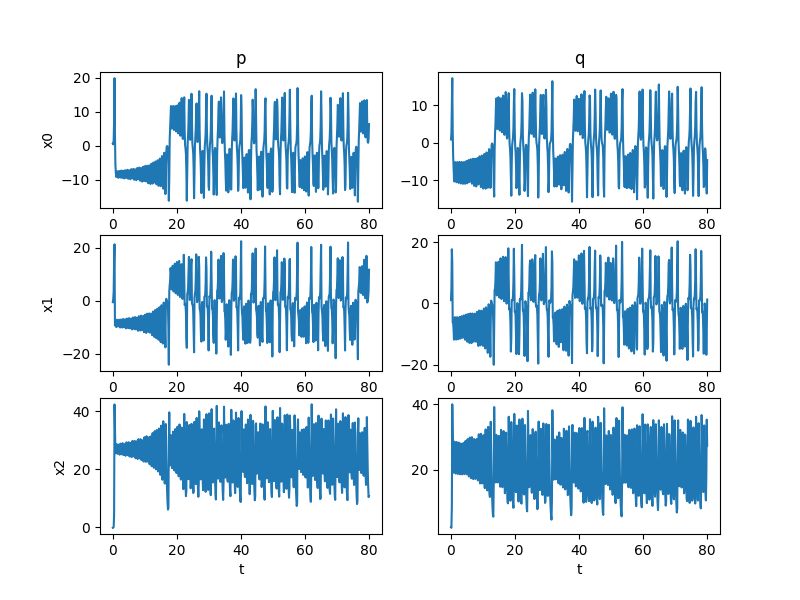

In [8]:
%matplotlib widget

import matplotlib.animation as animation

fig, axes = plt.subplots(3, 2, figsize=(8, 6))

axes[0, 0].set_title("p")
axes[0, 1].set_title("q")

axes[0, 0].set_ylabel("x0")
axes[1, 0].set_ylabel("x1")
axes[2, 0].set_ylabel("x2")

axes[2, 0].set_xlabel("t")
axes[2, 1].set_xlabel("t")

def update(frame):
    for i in range(3):
        axes[i, 0].clear()
        axes[i, 1].clear()

        axes[i, 0].plot(t, samples_p[frame, :, i].T)
        axes[i, 1].plot(t, samples_q[frame, :, i].T)
        
    axes[0, 0].set_title("p")
    axes[0, 1].set_title("q")

    axes[0, 0].set_ylabel("x0")
    axes[1, 0].set_ylabel("x1")
    axes[2, 0].set_ylabel("x2")

    axes[2, 0].set_xlabel("t")
    axes[2, 1].set_xlabel("t")

ani = animation.FuncAnimation(fig, update, frames=range(samples_p.shape[0]), interval=200)
ani.save("figures/lorentz.gif", writer="imagemagick")
plt.show()


In [9]:
@partial(jax.jit, static_argnums=(2,3))
def geometric_measure(xs_p, xs_q, num_bins=200, bw_method=0.5):
    """Geometric measure of the two trajectories."""
    N = xs_p.shape[0]
    M = xs_q.shape[0]
    d = xs_p.shape[-1]
    xs_p = xs_p.reshape(N, num_bins, -1, d)
    xs_q = xs_q.reshape(M, num_bins, -1, d)
    
    xs_p = jnp.transpose(xs_p, (1, 0, 2, 3))
    xs_q = jnp.transpose(xs_q, (1, 0, 2, 3))
    
    xs = jnp.concatenate([xs_p, xs_q], axis=1)

    def scan_fn(carry, val):
        kl_div = carry[0]
        xs_p, xs_q = jnp.split(val, [N], axis=0)
        xs_p = xs_p.reshape(-1, xs_p.shape[-1])
        xs_q = xs_q.reshape(-1, xs_q.shape[-1])
        print(xs_p.shape)
        print(xs_q.shape)
        kde_p = jax.scipy.stats.gaussian_kde(xs_p.T, bw_method=bw_method)
        kde_q = jax.scipy.stats.gaussian_kde(xs_q.T, bw_method=bw_method)
        kl_div += jnp.mean(kde_p.logpdf(xs_p.T) - kde_q.logpdf(xs_p.T)) / num_bins
        return (kl_div,), None
    
    kl_div, _ = jax.lax.scan(scan_fn, (0.,), xs)
    return kl_div[0]
        
        

In [10]:
def gaussian_filter1d(input_array, sigma):
    """
    1D Gaussian filter implementation using JAX.

    Parameters:
    - input_array: 1D array to be smoothed.
    - sigma: Standard deviation of the Gaussian kernel.

    Returns:
    - smoothed_array: Smoothed version of the input array.
    """
    size = int(6 * sigma + 1)
    kernel = jnp.exp(-(jnp.arange(size) - size // 2)**2 / (2 * sigma**2))
    kernel /= jnp.sum(kernel)

    smoothed_array = jax.scipy.signal.convolve(input_array, kernel, mode='same')

    return smoothed_array

In [11]:
def comput_normalized_smooth_psd(samples):
    f, psd = jax.scipy.signal.csd(samples, samples, axis=1)
    psd = jnp.absolute(psd)**2
    smoothed_psd = jax.vmap(jax.vmap(gaussian_filter1d, in_axes=(0, None)), in_axes=(-1, None))(psd, 10.)
    normalized_psd = smoothed_psd / jnp.sum(smoothed_psd, axis=-1, keepdims=True)
    return normalized_psd

def compute_temporal_measure(samples_p, samples_q):
    psd_p = comput_normalized_smooth_psd(samples_p)
    psd_q = comput_normalized_smooth_psd(samples_q)
    hellinger_distance = 1/jnp.sqrt(2) * jnp.linalg.norm(jnp.sqrt(psd_p) - jnp.sqrt(psd_q), axis=-1)
    return jnp.mean(hellinger_distance)

In [12]:
target_geometric_measure = geometric_measure(samples_p, samples_q)
print(target_geometric_measure)

(600, 3)
(600, 3)
0.26209572


In [13]:
target_geometric_measure = geometric_measure(samples_p, samples_p2)
print(target_geometric_measure)

0.04564338


In [14]:
target_temporal_measure = compute_temporal_measure(samples_p, samples_q)
print(target_temporal_measure)

0.23119767


In [15]:
target_geometric_measure = compute_temporal_measure(samples_p, samples_p2)
print(target_geometric_measure)

0.14388135


In [34]:
mean_p = samples_p.mean(axis=0)
std_p = samples_p.std(axis=0)

gaussian_noise = jax.random.normal(key, (samples_p.shape[0],) + mean_p.shape) 
samples_dummy = mean_p + std_p * gaussian_noise


In [33]:
compute_temporal_measure(samples_p, samples_dummy)

Array(0.642, dtype=float32)

In [35]:
@jax.jit
@jax.value_and_grad
def loss_fn1(x):
    
    return -geometric_measure(samples_p,x) + (target_temporal_measure - compute_temporal_measure(samples_p, x))**2


@jax.jit
@jax.value_and_grad
def loss_fn2(x):
    return -compute_temporal_measure(samples_p, x) + (target_geometric_measure - geometric_measure(samples_p, x))**2


In [36]:
samples_q_tilde = samples_q.copy()
for i in range(20):
    value, grad = loss_fn1(samples_q_tilde)
    samples_q_tilde = samples_q_tilde - 0.1*jnp.sign(grad)
    
    

In [38]:
geometric_measure(samples_p, samples_q_tilde)

Array(3.225, dtype=float32)

In [39]:
compute_temporal_measure(samples_p, samples_q_tilde)

Array(0.248, dtype=float32)

In [40]:
samples_q_tilde2 = samples_q.copy()
for i in range(20):
    value, grad = loss_fn2(samples_q_tilde2)
    samples_q_tilde2 = samples_q_tilde2 - 0.1*jnp.sign(grad)
    
    

In [41]:
geometric_measure(samples_p, samples_q_tilde2)

Array(0.152, dtype=float32)

In [42]:
compute_temporal_measure(samples_p, samples_q_tilde2)

Array(0.401, dtype=float32)

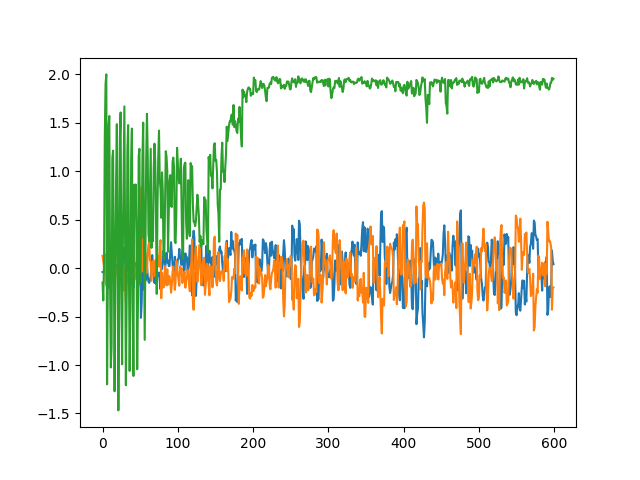

In [35]:
plt.figure()
plt.plot(jnp.mean((samples_q - samples_q_tilde), axis=0))

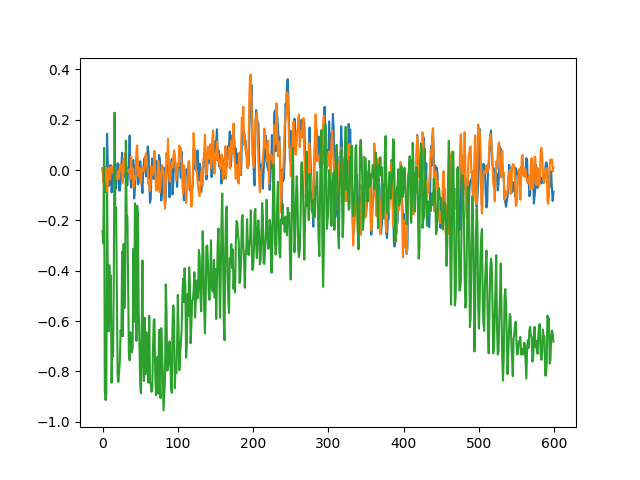

In [45]:
plt.figure()
plt.plot(jnp.mean((samples_q - samples_q_tilde2), axis=0))

MovieWriter imagemagick unavailable; using Pillow instead.


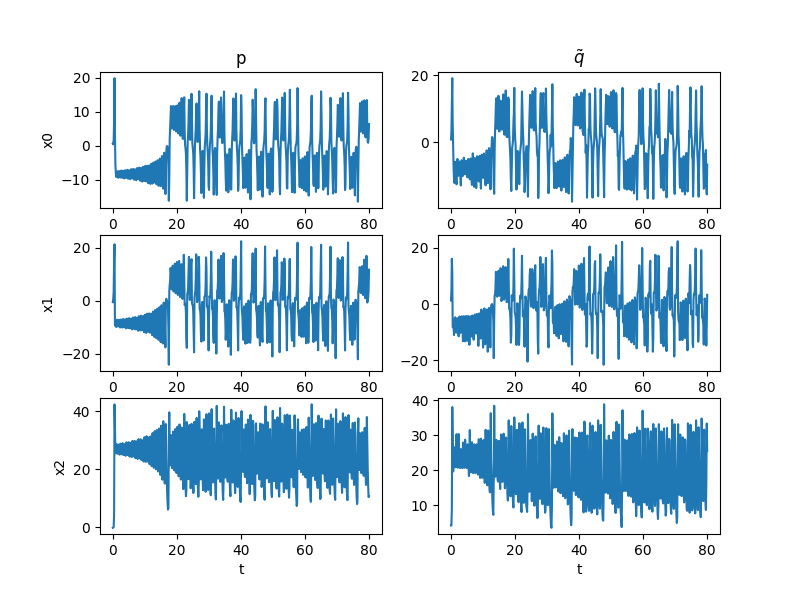

In [46]:
%matplotlib widget

import matplotlib.animation as animation

fig, axes = plt.subplots(3, 2, figsize=(8, 6))

axes[0, 0].set_title("p")
axes[0, 1].set_title(r"$\tilde{q}$")

axes[0, 0].set_ylabel("x0")
axes[1, 0].set_ylabel("x1")
axes[2, 0].set_ylabel("x2")

axes[2, 0].set_xlabel("t")
axes[2, 1].set_xlabel("t")

def update(frame):
    for i in range(3):
        axes[i, 0].clear()
        axes[i, 1].clear()

        axes[i, 0].plot(t, samples_p[frame, :, i].T)
        axes[i, 1].plot(t, samples_q_tilde[frame, :, i].T)
        
    axes[0, 0].set_title("p")
    axes[0, 1].set_title(r"$\tilde{q}$")

    axes[0, 0].set_ylabel("x0")
    axes[1, 0].set_ylabel("x1")
    axes[2, 0].set_ylabel("x2")

    axes[2, 0].set_xlabel("t")
    axes[2, 1].set_xlabel("t")

ani = animation.FuncAnimation(fig, update, frames=range(samples_p.shape[0]), interval=200)
ani.save("figures/lorentz_tilde1.gif", writer="imagemagick")
plt.show()


MovieWriter imagemagick unavailable; using Pillow instead.


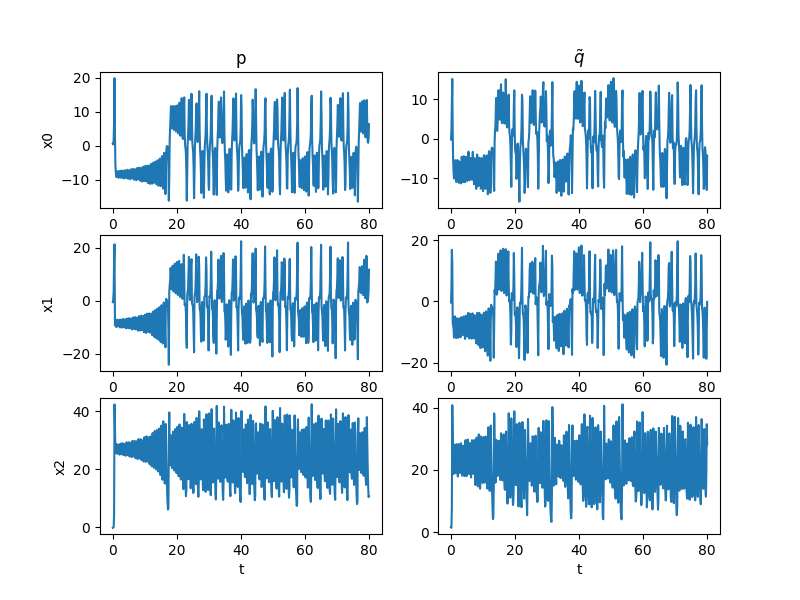

In [47]:
%matplotlib widget

import matplotlib.animation as animation

fig, axes = plt.subplots(3, 2, figsize=(8, 6))

axes[0, 0].set_title("p")
axes[0, 1].set_title(r"$\tilde{q}$")

axes[0, 0].set_ylabel("x0")
axes[1, 0].set_ylabel("x1")
axes[2, 0].set_ylabel("x2")

axes[2, 0].set_xlabel("t")
axes[2, 1].set_xlabel("t")

def update(frame):
    for i in range(3):
        axes[i, 0].clear()
        axes[i, 1].clear()

        axes[i, 0].plot(t, samples_p[frame, :, i].T)
        axes[i, 1].plot(t, samples_q_tilde2[frame, :, i].T)
        
    axes[0, 0].set_title("p")
    axes[0, 1].set_title(r"$\tilde{q}$")

    axes[0, 0].set_ylabel("x0")
    axes[1, 0].set_ylabel("x1")
    axes[2, 0].set_ylabel("x2")

    axes[2, 0].set_xlabel("t")
    axes[2, 1].set_xlabel("t")

ani = animation.FuncAnimation(fig, update, frames=range(samples_p.shape[0]), interval=200)
ani.save("figures/lorentz_tilde2.gif", writer="imagemagick")
plt.show()
